# 전처리 3단계 — 파생변수: 강우효과 RNE

> v2: 기존 2025년 처리 흐름을 유지하되, 처리 범위를 2020~2025년 봄철(2~5월) 전체로 확장하고 대용량 검증은 DuckDB 기반으로 보강했습니다.

## 왜 RNE가 필요한가?

> 어제·그제 많은 비가 왔다면 숲이 촉촉해서 산불이 잘 안 납니다.  
> RNE(Rain Effect)는 **최근 3일의 강수량이 산불 위험을 얼마나 낮추는지**를 수치로 표현합니다.
>
> - RNE = 1.0 → 최근 3일 비 없음 → 산불 위험 그대로
> - RNE = 0.1 → 최근 3일 폭우 → 산불 위험 90% 감소

## 계산 방법 (2단계)

### 1단계: 강수 등급 분류
| 일강수량 | 등급(RN) |
|---------|----------|
| 0 ~ 1mm 미만 | 0 |
| 1 ~ 5mm 미만 | 1 |
| 5 ~ 10mm 미만 | 2 |
| 10mm 이상 | 3 |

### 2단계: RNE_Temp → RNE 변환
```
RNE_Temp = 등급(2일전) + 등급(1일전) + 등급(당일)
```
| RNE_Temp | RNE (강우효과) |
|----------|---------------|
| 0 ~ 1 | 1.0 (비 효과 없음) |
| 1 ~ 2 | 1.0 |
| 2 ~ 3 | 0.5 |
| 3 ~ 4 | 0.4 |
| 4 ~ 5 | 0.3 |
| 5 ~ 6 | 0.2 |
| 6 이상 | 0.1 (비 효과 최대) |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import duckdb
import os, time, warnings, gc
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ============================================================
# 0. 경로 설정
#    - .project-root 파일이 있으면 프로젝트 루트로 사용
#    - 없으면 현재 작업 폴더 기준으로 상위 폴더를 탐색
# ============================================================

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    start = start.resolve()

    # 1순위: .project-root 파일
    for path in [start, *start.parents]:
        if (path / '.project-root').exists():
            return path

    # 2순위: preprocessing 폴더가 있는 위치
    for path in [start, *start.parents]:
        if (path / 'preprocessing').exists():
            return path

    # 실패 시 현재 폴더
    return start


BASE_PATH = find_project_root()

# 기존 코드 흐름을 최대한 유지하기 위해 변수명은 그대로 사용
# 필요하면 아래 3개 경로만 프로젝트 구조에 맞게 수정하면 됩니다.
DATA_PATH   = BASE_PATH / 'preprocessing'
SCALED_PATH = DATA_PATH / 'weather_scaled'
OUTPUT_PATH = DATA_PATH / 'derived'
FIGURE_PATH = DATA_PATH / 'PREP03'

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
FIGURE_PATH.mkdir(parents=True, exist_ok=True)

# 2020~2025년 봄철(2~5월)
MONTHS = [
    f'{year}-{month:02d}'
    for year in range(2020, 2026)
    for month in [2, 3, 4, 5]
]

# 등급 분류 기준
RN_BINS   = [0, 1, 5, 10, np.inf]
RN_LABELS = [0, 1, 2, 3]

# RNE_Temp → RNE 매핑
def rne_from_temp(temp_series):
    conditions = [
        temp_series < 2,
        temp_series < 3,
        temp_series < 4,
        temp_series < 5,
        temp_series < 6,
    ]
    choices = [1.0, 0.5, 0.4, 0.3, 0.2]
    return np.select(conditions, choices, default=0.1).astype('float32')


def is_contiguous_month(prev_month, curr_month):
    """
    이전 처리 월과 현재 처리 월이 실제로 연속된 월인지 확인합니다.
    예: 2025-02 → 2025-03 True
        2025-05 → 2026-02 False

    RNE는 최근 3일 강수량만 사용하므로, 5월과 다음 해 2월 사이에는
    버퍼를 이어붙이면 안 됩니다.
    """
    if prev_month is None:
        return False

    prev = pd.Period(prev_month, freq='M')
    curr = pd.Period(curr_month, freq='M')
    return curr == prev + 1


def read_month_partition(base_path, month, columns):
    """
    month=YYYY-MM 폴더 안의 parquet 파일만 읽습니다.
    데이터셋 루트에 ipynb/png/csv 등이 있어도 읽기 오류가 나지 않도록
    월 파티션 폴더의 *.parquet 파일만 명시적으로 읽습니다.
    """
    month_path = Path(base_path) / f'month={month}'

    if not month_path.exists():
        raise FileNotFoundError(f'월 파티션 폴더가 없습니다: {month_path}')

    parquet_files = sorted(month_path.glob('*.parquet'))

    if len(parquet_files) == 0:
        raise FileNotFoundError(f'Parquet 파일이 없습니다: {month_path}')

    df = pd.read_parquet(
        parquet_files,
        columns=columns,
        engine='pyarrow'
    )

    df['month'] = month
    return df


print('설정 완료')
print(f'BASE_PATH   : {BASE_PATH}')
print(f'SCALED_PATH : {SCALED_PATH}')
print(f'OUTPUT_PATH : {OUTPUT_PATH}')
print(f'FIGURE_PATH : {FIGURE_PATH}')
print(f'처리 월 수   : {len(MONTHS)}개')
print(MONTHS)


설정 완료
BASE_PATH   : C:\SKN projects\weather
SCALED_PATH : C:\SKN projects\weather\preprocessing\weather_scaled
OUTPUT_PATH : C:\SKN projects\weather\preprocessing\derived
FIGURE_PATH : C:\SKN projects\weather\preprocessing\PREP03
처리 월 수   : 24개
['2020-02', '2020-03', '2020-04', '2020-05', '2021-02', '2021-03', '2021-04', '2021-05', '2022-02', '2022-03', '2022-04', '2022-05', '2023-02', '2023-03', '2023-04', '2023-05', '2024-02', '2024-03', '2024-04', '2024-05', '2025-02', '2025-03', '2025-04', '2025-05']


---
## Step 1. 계산 예시 확인

In [2]:
test = pd.DataFrame({
    'grid_id':    ['A']*6,
    'date':       pd.date_range('2025-03-01', periods=6),
    'rn_day_mean':[0.0, 0.5, 3.0, 12.0, 7.5, 0.0]
})

test['rn_class']  = pd.cut(test['rn_day_mean'], bins=RN_BINS, labels=RN_LABELS, right=False).astype(int)
test['rn_class1'] = test.groupby('grid_id')['rn_class'].shift(1).fillna(0).astype(int)
test['rn_class2'] = test.groupby('grid_id')['rn_class'].shift(2).fillna(0).astype(int)
test['rne_temp']  = test['rn_class2'] + test['rn_class1'] + test['rn_class']
test['rne']       = rne_from_temp(test['rne_temp'])

print('=== 계산 예시 ===')
print(test[['date','rn_day_mean','rn_class','rn_class1','rn_class2','rne_temp','rne']].to_string(index=False))
print()
print('해석:')
print('  - 1~2일: 비 없음 -> RNE=1.0 (위험 감소 없음)')
print('  - 4~5일: 연속 비 -> RNE가 낮아져 산불 위험 감소')
print('  - 6일:   오늘 비 없지만 어제·그제 비가 있었으므로 RNE<1.0')

=== 계산 예시 ===
      date  rn_day_mean  rn_class  rn_class1  rn_class2  rne_temp  rne
2025-03-01          0.0         0          0          0         0  1.0
2025-03-02          0.5         0          0          0         0  1.0
2025-03-03          3.0         1          0          0         1  1.0
2025-03-04         12.0         3          1          0         4  0.3
2025-03-05          7.5         2          3          1         6  0.1
2025-03-06          0.0         0          2          3         5  0.2

해석:
  - 1~2일: 비 없음 -> RNE=1.0 (위험 감소 없음)
  - 4~5일: 연속 비 -> RNE가 낮아져 산불 위험 감소
  - 6일:   오늘 비 없지만 어제·그제 비가 있었으므로 RNE<1.0


---
## Step 2. 전체 데이터 RNE 계산 (월별 + 2일 버퍼 이월)

기존 v1의 월별 처리 흐름은 유지하되, 처리 범위를 2020~2025년 2~5월 전체로 확장하였다.

주의할 점은 `2020-05 → 2021-02`처럼 실제로 연속되지 않은 월 사이에는 이전 월의 마지막 2일 버퍼를 사용하면 안 된다는 것이다.  
따라서 같은 연도 안에서 `2월→3월→4월→5월`은 버퍼를 이어가고, 다음 해 2월로 넘어갈 때는 버퍼를 초기화한다.


In [3]:
start_total = time.time()
buffer     = None
prev_month = None
LAG_DAYS   = 2

RNE_OUT_PATH = Path(OUTPUT_PATH) / 'rne'
RNE_OUT_PATH.mkdir(parents=True, exist_ok=True)

for m in MONTHS:
    t0 = time.time()
    print(f'[{m}] 읽기...', end=' ', flush=True)

    # --------------------------------------------------------
    # 1) 해당 월 데이터 읽기
    #    SCALED_PATH 전체를 읽지 않고 month=YYYY-MM 폴더의 parquet만 읽음
    # --------------------------------------------------------
    df_m = read_month_partition(
        SCALED_PATH,
        m,
        columns=['grid_id', 'date', 'rn_day_mean']
    )

    df_m['date'] = pd.to_datetime(df_m['date'])

    # --------------------------------------------------------
    # 2) 버퍼(이전 달 마지막 2일) 붙이기
    #    단, 실제로 연속된 월일 때만 사용
    # --------------------------------------------------------
    use_buffer = buffer is not None and is_contiguous_month(prev_month, m)

    if use_buffer:
        df_work = pd.concat([buffer, df_m], ignore_index=True)
    else:
        df_work = df_m.copy()
        buffer = None

    df_work = df_work.sort_values(['grid_id', 'date']).reset_index(drop=True)

    # --------------------------------------------------------
    # 3) 강수 등급 분류
    # --------------------------------------------------------
    df_work['rn_class'] = pd.cut(
        df_work['rn_day_mean'],
        bins=RN_BINS, labels=RN_LABELS, right=False
    ).astype('int8')

    # --------------------------------------------------------
    # 4) 1일전, 2일전 lag
    #    월 첫날에 버퍼가 없으면 이전 강수 등급은 0으로 채움
    # --------------------------------------------------------
    grp = df_work.groupby('grid_id', sort=False)['rn_class']
    df_work['rn_class1'] = grp.shift(1).fillna(0).astype('int8')
    df_work['rn_class2'] = grp.shift(2).fillna(0).astype('int8')

    # --------------------------------------------------------
    # 5) RNE_Temp 합산 & RNE 매핑
    # --------------------------------------------------------
    df_work['rne_temp'] = (
        df_work['rn_class2'] + df_work['rn_class1'] + df_work['rn_class']
    ).astype('int8')

    df_work['rne'] = rne_from_temp(df_work['rne_temp'])

    # --------------------------------------------------------
    # 6) 버퍼 행 제거: 현재 월 결과만 저장
    # --------------------------------------------------------
    month_start = pd.Timestamp(m + '-01')
    month_end   = month_start + pd.offsets.MonthEnd(0)

    df_result = df_work[
        (df_work['date'] >= month_start) &
        (df_work['date'] <= month_end)
    ].copy()

    # --------------------------------------------------------
    # 7) 다음 달 버퍼 저장: 현재 월 마지막 2일 원자료
    # --------------------------------------------------------
    last_2 = sorted(df_m['date'].unique())[-LAG_DAYS:]
    buffer = df_m[df_m['date'].isin(last_2)][
        ['grid_id', 'date', 'rn_day_mean']
    ].copy()

    prev_month = m

    # --------------------------------------------------------
    # 8) 저장
    # --------------------------------------------------------
    out_dir = RNE_OUT_PATH / f'month={m}'
    out_dir.mkdir(parents=True, exist_ok=True)

    df_result[['grid_id', 'date', 'rn_class', 'rne_temp', 'rne']].to_parquet(
        out_dir / 'data.parquet',
        index=False,
        engine='pyarrow',
        compression='snappy'
    )

    elapsed = time.time() - t0
    rne1_pct = (df_result['rne'] == 1.0).mean() * 100
    buffer_msg = '버퍼사용' if use_buffer else '버퍼초기화'
    print(f'{len(df_result):,}행, RNE=1.0비율:{rne1_pct:.1f}%, {buffer_msg}, {elapsed:.1f}초')

    # 메모리 정리
    del df_m, df_work, df_result
    gc.collect()

print(f'\n전체 완료: {(time.time()-start_total)/60:.1f}분')
print(f'저장 위치: {RNE_OUT_PATH}')


[2020-02] 읽기... 

7,917,029행, RNE=1.0비율:82.0%, 버퍼초기화, 11.2초
[2020-03] 읽기... 8,463,031행, RNE=1.0비율:91.7%, 버퍼사용, 11.8초
[2020-04] 읽기... 8,190,030행, RNE=1.0비율:88.9%, 버퍼사용, 8.9초
[2020-05] 읽기... 8,463,031행, RNE=1.0비율:64.5%, 버퍼사용, 10.0초
[2021-02] 읽기... 7,644,028행, RNE=1.0비율:100.0%, 버퍼초기화, 7.5초
[2021-03] 읽기... 8,463,031행, RNE=1.0비율:80.9%, 버퍼사용, 9.6초
[2021-04] 읽기... 8,190,030행, RNE=1.0비율:76.1%, 버퍼사용, 10.3초
[2021-05] 읽기... 8,463,031행, RNE=1.0비율:54.3%, 버퍼사용, 9.9초
[2022-02] 읽기... 7,644,028행, RNE=1.0비율:99.9%, 버퍼초기화, 8.0초
[2022-03] 읽기... 8,463,031행, RNE=1.0비율:74.1%, 버퍼사용, 9.6초
[2022-04] 읽기... 8,190,030행, RNE=1.0비율:77.2%, 버퍼사용, 8.5초
[2022-05] 읽기... 8,463,031행, RNE=1.0비율:95.2%, 버퍼사용, 9.8초
[2023-02] 읽기... 7,644,028행, RNE=1.0비율:98.7%, 버퍼초기화, 8.9초
[2023-03] 읽기... 8,463,031행, RNE=1.0비율:96.8%, 버퍼사용, 11.8초
[2023-04] 읽기... 8,190,030행, RNE=1.0비율:83.8%, 버퍼사용, 9.7초
[2023-05] 읽기... 8,463,031행, RNE=1.0비율:73.4%, 버퍼사용, 12.0초
[2024-02] 읽기... 7,917,029행, RNE=1.0비율:80.7%, 버퍼초기화, 12.3초
[2024-03] 읽기... 8,463,031행, RNE=1.0비율:86.2%, 버퍼사용, 

---
## Step 3. 결과 검증

> **검증 포인트**  
> 1. RNE 값이 [0.1, 0.2, 0.3, 0.4, 0.5, 1.0] 6가지만 존재하는가?  
> 2. RNE=1.0 (비 없는 날)이 가장 많은가?  
> 3. 실제 비가 온 날에 RNE가 내려가는가?  
> 4. 6개년 전체 데이터를 한 번에 pandas로 로드하지 않고 DuckDB로 집계하는가?


In [4]:
RNE_PATH = Path(OUTPUT_PATH) / 'rne'

# DuckDB는 parquet 파일을 메모리에 모두 올리지 않고 직접 스캔하며 집계 가능
con = duckdb.connect()

RNE_GLOB = (RNE_PATH / 'month=*' / '*.parquet').as_posix()
SCALED_GLOB = (SCALED_PATH / 'month=*' / '*.parquet').as_posix()

print('RNE_GLOB   :', RNE_GLOB)
print('SCALED_GLOB:', SCALED_GLOB)

print('\n=== 월별 RNE 분포 ===')

rne_dist = con.execute(f"""
    SELECT
        month,
        rne,
        COUNT(*) AS cnt
    FROM read_parquet('{RNE_GLOB}', hive_partitioning=true)
    GROUP BY month, rne
    ORDER BY month, rne
""").fetchdf()

month_totals = con.execute(f"""
    SELECT
        month,
        COUNT(*) AS total
    FROM read_parquet('{RNE_GLOB}', hive_partitioning=true)
    GROUP BY month
    ORDER BY month
""").fetchdf()

for m in MONTHS:
    sub = rne_dist[rne_dist['month'] == m]
    total = int(month_totals.loc[month_totals['month'] == m, 'total'].iloc[0])

    print(f'\n[{m}] 총 {total:,}행')
    for _, row in sub.iterrows():
        v = float(row['rne'])
        cnt = int(row['cnt'])
        bar = '|' * int(cnt / total * 50)
        print(f'  RNE={v:.1f}: {cnt:>10,}건 ({cnt/total*100:5.1f}%) {bar}')


RNE_GLOB   : C:/SKN projects/weather/preprocessing/derived/rne/month=*/*.parquet
SCALED_GLOB: C:/SKN projects/weather/preprocessing/weather_scaled/month=*/*.parquet

=== 월별 RNE 분포 ===

[2020-02] 총 7,917,029행
  RNE=0.1:     13,801건 (  0.2%) 
  RNE=0.2:     23,283건 (  0.3%) 
  RNE=0.3:    199,807건 (  2.5%) |
  RNE=0.4:    447,792건 (  5.7%) ||
  RNE=0.5:    741,297건 (  9.4%) ||||
  RNE=1.0:  6,491,049건 ( 82.0%) ||||||||||||||||||||||||||||||||||||||||

[2020-03] 총 8,463,031행
  RNE=0.3:     67,306건 (  0.8%) 
  RNE=0.4:    195,158건 (  2.3%) |
  RNE=0.5:    439,258건 (  5.2%) ||
  RNE=1.0:  7,761,309건 ( 91.7%) |||||||||||||||||||||||||||||||||||||||||||||

[2020-04] 총 8,190,030행
  RNE=0.1:        122건 (  0.0%) 
  RNE=0.2:     13,639건 (  0.2%) 
  RNE=0.3:     42,151건 (  0.5%) 
  RNE=0.4:    223,792건 (  2.7%) |
  RNE=0.5:    632,317건 (  7.7%) |||
  RNE=1.0:  7,278,009건 ( 88.9%) ||||||||||||||||||||||||||||||||||||||||||||

[2020-05] 총 8,463,031행
  RNE=0.1:     39,367건 (  0.5%) 
  RNE=0.2:    25

In [5]:
# 강수 있는 날 RNE 변화 추적 (샘플 격자)
# 전체 데이터를 pandas로 merge하지 않고 DuckDB에서 대상 격자만 찾는다.

target = con.execute(f"""
    SELECT
        r.grid_id,
        COUNT(*) AS rainy_days
    FROM read_parquet('{RNE_GLOB}', hive_partitioning=true) r
    JOIN read_parquet('{SCALED_GLOB}', hive_partitioning=true) w
      ON r.grid_id = w.grid_id
     AND CAST(r.date AS DATE) = CAST(w.date AS DATE)
    WHERE w.rn_day_mean >= 5
    GROUP BY r.grid_id
    ORDER BY rainy_days DESC
    LIMIT 1
""").fetchone()

if target is None:
    raise ValueError('5mm 이상 강수일이 있는 격자를 찾지 못했습니다.')

target_grid, rainy_day_count = target

print(f'검증 격자: {target_grid} (비 5mm+ 날 {rainy_day_count}일)')

df_grid = con.execute(f"""
    SELECT
        CAST(r.date AS DATE) AS date,
        w.rn_day_mean,
        r.rn_class,
        r.rne_temp,
        r.rne,
        r.month
    FROM read_parquet('{RNE_GLOB}', hive_partitioning=true) r
    JOIN read_parquet('{SCALED_GLOB}', hive_partitioning=true) w
      ON r.grid_id = w.grid_id
     AND CAST(r.date AS DATE) = CAST(w.date AS DATE)
    WHERE r.grid_id = '{target_grid}'
    ORDER BY CAST(r.date AS DATE)
""").fetchdf()

df_grid['date'] = pd.to_datetime(df_grid['date'])

# 비가 온 날 전후 5일 윈도우 출력
rainy_days = df_grid[df_grid['rn_day_mean'] >= 5]['date'].values

if len(rainy_days) > 0:
    pivot_date = pd.Timestamp(rainy_days[len(rainy_days)//2])
    window = pd.date_range(
        pivot_date - pd.Timedelta(days=2),
        pivot_date + pd.Timedelta(days=4)
    )

    df_show = df_grid[df_grid['date'].isin(window)]

    print(df_show[['date','rn_day_mean','rn_class','rne_temp','rne']].to_string(index=False))
    print()
    print('해석: 비가 오면 rn_class가 올라가고, 다음날부터 rne_temp가 높아져 rne가 낮아짐')


검증 격자: 11369_19651 (비 5mm+ 날 54일)
      date  rn_day_mean  rn_class  rne_temp  rne
2022-04-24       0.0000         0         0  1.0
2022-04-25       0.0000         0         0  1.0
2022-04-26      12.0875         3         3  0.4
2022-04-27       1.8000         1         4  0.3
2022-04-28       0.0000         0         4  0.3
2022-04-29      12.2000         3         4  0.3
2022-04-30       2.0750         1         4  0.3

해석: 비가 오면 rn_class가 올라가고, 다음날부터 rne_temp가 높아져 rne가 낮아짐


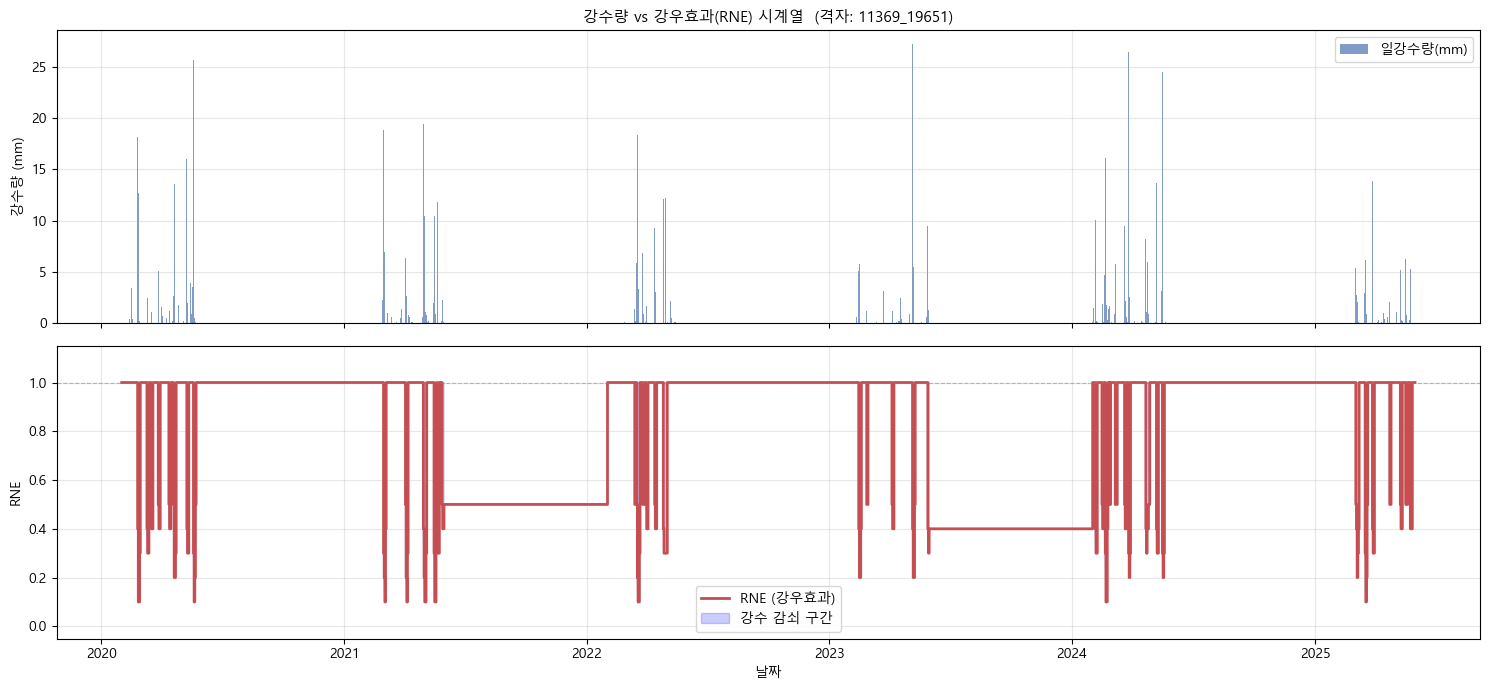

그래프 저장: C:\SKN projects\weather\preprocessing\PREP03\PREP_03_RNE시계열_6years.png


In [6]:
# 시각화: 강수량 vs RNE 시계열
# 6개년 전체를 한 그림에 그리면 복잡하므로, 샘플 격자의 전체 시계열을 그대로 확인한다.

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

ax1.bar(df_grid['date'], df_grid['rn_day_mean'],
        color='#4C72B0', alpha=0.7, width=1, label='일강수량(mm)')
ax1.set_ylabel('강수량 (mm)')
ax1.set_title(f'강수량 vs 강우효과(RNE) 시계열  (격자: {target_grid})', fontsize=11)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.step(df_grid['date'], df_grid['rne'], color='#C44E52',
         linewidth=2, where='post', label='RNE (강우효과)')
ax2.set_ylim(-0.05, 1.15)
ax2.set_ylabel('RNE')
ax2.set_xlabel('날짜')
ax2.axhline(1.0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax2.fill_between(df_grid['date'], df_grid['rne'], 1.0,
                 where=(df_grid['rne'] < 1.0),
                 alpha=0.2, color='blue', label='강수 감쇠 구간')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()

fig_path = Path(FIGURE_PATH) / 'PREP_03_RNE시계열_6years.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()

print(f'그래프 저장: {fig_path}')


=== 월별 RNE 요약 ===
월               RNE=1.0    RNE<1.0    RNE=0.1(최저)
----------------------------------------------------
2020-02           82.0%      18.0%          0.17%
2020-03           91.7%       8.3%          0.00%
2020-04           88.9%      11.1%          0.00%
2020-05           64.5%      35.5%          0.47%
2021-02          100.0%       0.0%          0.00%
2021-03           80.9%      19.1%          0.14%
2021-04           76.1%      23.9%          1.09%
2021-05           54.3%      45.7%          5.62%
2022-02           99.9%       0.1%          0.00%
2022-03           74.1%      25.9%          1.09%
2022-04           77.2%      22.8%          0.00%
2022-05           95.2%       4.8%          0.00%
2023-02           98.7%       1.3%          0.01%
2023-03           96.8%       3.2%          0.00%
2023-04           83.8%      16.2%          0.01%
2023-05           73.4%      26.6%          5.20%
2024-02           80.7%      19.3%          0.63%
2024-03           86.2%      

,month,total,rne_1_cnt,rne_lt_1_cnt,rne_01_cnt,rne_1_pct,rne_lt_1_pct,rne_01_pct
0,2020-02,7917029,6491049.0,1425980.0,13801.0,81.988445,18.011555,0.174320
1,2020-03,8463031,7761309.0,701722.0,0.0,91.708384,8.291616,0.000000
2,2020-04,8190030,7278009.0,912021.0,122.0,88.864253,11.135747,0.001490
3,2020-05,8463031,5455478.0,3007553.0,39367.0,64.462460,35.537540,0.465164
4,2021-02,7644028,7644028.0,0.0,0.0,100.000000,0.000000,0.000000
5,2021-03,8463031,6846084.0,1616947.0,11970.0,80.893996,19.106004,0.141439
6,2021-04,8190030,6231783.0,1958247.0,88988.0,76.089868,23.910132,1.086541
7,2021-05,8463031,4595062.0,3867969.0,475256.0,54.295701,45.704299,5.615671
8,2022-02,7644028,7633411.0,10617.0,0.0,99.861107,0.138893,0.000000
9,2022-03,8463031,6271783.0,2191248.0,92431.0,74.108000,25.892000,1.092174


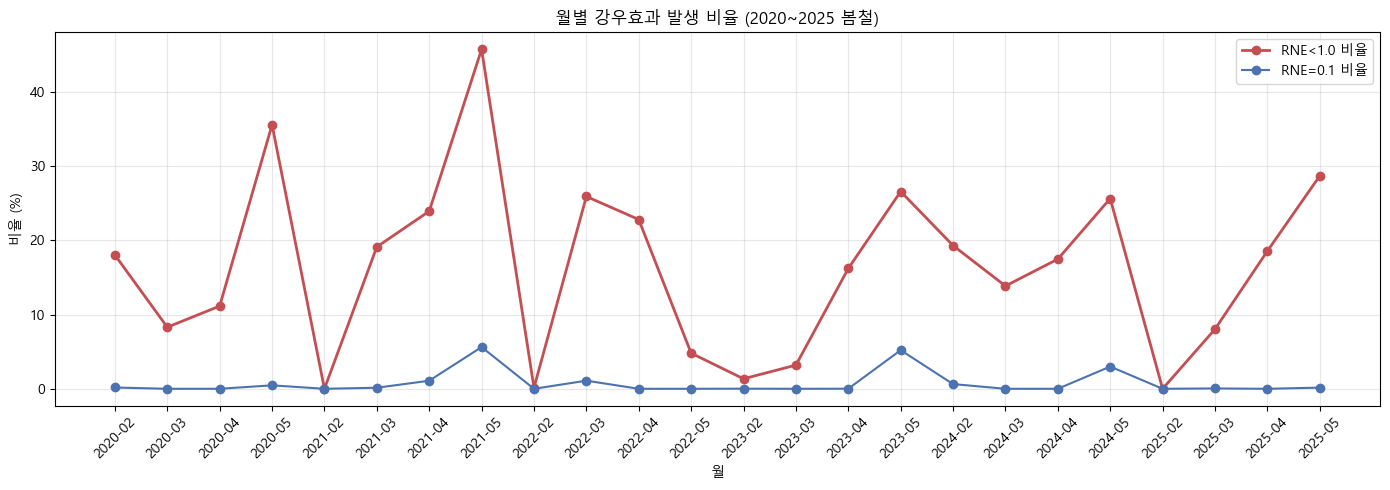

그래프 저장: C:\SKN projects\weather\preprocessing\PREP03\PREP_03_RNE월별요약_6years.png


In [7]:
# 월별 요약 통계
print('=== 월별 RNE 요약 ===')
print(f'{"월":<12} {"RNE=1.0":>10} {"RNE<1.0":>10} {"RNE=0.1(최저)":>14}')
print('-' * 52)

monthly_summary = con.execute(f"""
    SELECT
        month,
        COUNT(*) AS total,
        SUM(CASE WHEN rne = 1.0 THEN 1 ELSE 0 END) AS rne_1_cnt,
        SUM(CASE WHEN rne < 1.0 THEN 1 ELSE 0 END) AS rne_lt_1_cnt,
        SUM(CASE WHEN rne = 0.1 THEN 1 ELSE 0 END) AS rne_01_cnt
    FROM read_parquet('{RNE_GLOB}', hive_partitioning=true)
    GROUP BY month
    ORDER BY month
""").fetchdf()

monthly_summary['rne_1_pct']    = monthly_summary['rne_1_cnt'] / monthly_summary['total'] * 100
monthly_summary['rne_lt_1_pct'] = monthly_summary['rne_lt_1_cnt'] / monthly_summary['total'] * 100
monthly_summary['rne_01_pct']   = monthly_summary['rne_01_cnt'] / monthly_summary['total'] * 100

for _, row in monthly_summary.iterrows():
    print(
        f"{row['month']:<12} "
        f"{row['rne_1_pct']:>9.1f}% "
        f"{row['rne_lt_1_pct']:>9.1f}% "
        f"{row['rne_01_pct']:>13.2f}%"
    )

print()
print('RNE=1.0 : 최근 3일 비 없음 → 산불 위험 감쇠 없음')
print('RNE<1.0 : 최근 3일 안에 비가 있었음 → 위험 감소')
print('RNE=0.1 : 최근 3일 연속 폭우 → 위험 90% 감소')

display(monthly_summary)

# 월별 RNE<1.0 비율 시각화
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly_summary['month'], monthly_summary['rne_lt_1_pct'],
        marker='o', linewidth=2, color='#C44E52', label='RNE<1.0 비율')
ax.plot(monthly_summary['month'], monthly_summary['rne_01_pct'],
        marker='o', linewidth=1.5, color='#4C72B0', label='RNE=0.1 비율')

ax.set_title('월별 강우효과 발생 비율 (2020~2025 봄철)', fontsize=12)
ax.set_xlabel('월')
ax.set_ylabel('비율 (%)')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

fig_path = Path(FIGURE_PATH) / 'PREP_03_RNE월별요약_6years.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()

print(f'그래프 저장: {fig_path}')


---
## 최종 요약

In [8]:
print('=' * 55)
print('  파생변수 3: 강우효과 RNE 생성 완료')
print('=' * 55)
print(f"""
  처리 범위
  - 2020~2025년 봄철(2~5월), 총 {len(MONTHS)}개월

  공식
  RNE_Temp = 등급(2일전) + 등급(1일전) + 등급(당일)
  등급: <1mm=0, 1~5mm=1, 5~10mm=2, 10mm+=3

  저장 컬럼
  - rn_class  : 당일 강수 등급 (0~3)
  - rne_temp  : 3일 강수 등급 합산 (0~9)
  - rne       : 최종 강우효과 (0.1~1.0)

  저장 위치
  - {RNE_OUT_PATH}

  대용량 처리 보완
  - 월별 파티션 단위 처리
  - 연속 월에만 이전 2일 버퍼 사용
  - 5월 → 다음 해 2월 전환 시 버퍼 초기화
  - 전체 검증은 DuckDB 기반 집계로 수행

  DWI 공식에서의 역할
  DWI = PreDWI_등급 × RNE
  -> RNE=1.0 : 비 없음, PreDWI 그대로 반영
  -> RNE=0.1 : 폭우 지속, PreDWI를 90% 감소

  다음 단계
  - 파생변수 4: 일 가중치 (w_d)
    월/일 기준 산불 위험 계절 가중치
""")
print('=' * 55)


  파생변수 3: 강우효과 RNE 생성 완료

  처리 범위
  - 2020~2025년 봄철(2~5월), 총 24개월

  공식
  RNE_Temp = 등급(2일전) + 등급(1일전) + 등급(당일)
  등급: <1mm=0, 1~5mm=1, 5~10mm=2, 10mm+=3

  저장 컬럼
  - rn_class  : 당일 강수 등급 (0~3)
  - rne_temp  : 3일 강수 등급 합산 (0~9)
  - rne       : 최종 강우효과 (0.1~1.0)

  저장 위치
  - C:\SKN projects\weather\preprocessing\derived\rne

  대용량 처리 보완
  - 월별 파티션 단위 처리
  - 연속 월에만 이전 2일 버퍼 사용
  - 5월 → 다음 해 2월 전환 시 버퍼 초기화
  - 전체 검증은 DuckDB 기반 집계로 수행

  DWI 공식에서의 역할
  DWI = PreDWI_등급 × RNE
  -> RNE=1.0 : 비 없음, PreDWI 그대로 반영
  -> RNE=0.1 : 폭우 지속, PreDWI를 90% 감소

  다음 단계
  - 파생변수 4: 일 가중치 (w_d)
    월/일 기준 산불 위험 계절 가중치

